In [1]:
import numpy as np

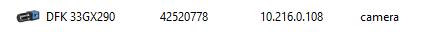

# 1er étape : récupéré les images de la cam 

In [3]:
! python -m pip install imagingcontrol4 

   ---------------------------------------- 0.0/11.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.5 MB 217.9 kB/s eta 0:00:53
   ---------------------------------------- 0.0/11.5 MB 217.9 kB/s eta 0:00:53
   ---------------------------------------- 0.1/11.5 MB 326.1 kB/s eta 0:00:36
   ---------------------------------------- 0.1/11.5 MB 655.8 kB/s eta 0:00:18
   - -------------------------------------- 0.3/11.5 MB 1.2 MB/s eta 0:00:10
   --- ------------------------------------ 0.9/11.5 MB 3.1 MB/s eta 0:00:04
   ----- ---------------------------------- 1.7/11.5 MB 4.9 MB/s eta 0:00:02
   ------ --------------------------------- 2.0/11.5 MB 5.1 MB/s eta 0:00:02
   -------- ------------------------------- 2.4/11.5 MB 5.5 MB/s eta 0:00:02
   -------- ------------------------------- 2.4/11.5 MB 5.5 MB/s eta 0:00:02
   -------- ------------------------------- 2.4/11.5 MB 5.5 MB/s eta 0:00:02
   --

In [2]:
import imagingcontrol4 as ic4
import time 
ic4.Library.init()



In [3]:
# trouver la caméra 
devices = ic4.DeviceEnum.devices()

print(devices)
for dev in devices:
    print(dev.model_name)
    print(dev.serial)
    print(dev.unique_name)
    print("-----")



[DeviceInfo(model_name='DFK 33GX290', serial='42520781', version='Rev 3186, FPGA GigE3LM-IMX:131')]
DFK 33GX290
42520781
The Imaging Source Europe GmbH-ic4-gentl-gev-42520781
-----


In [5]:
import imagingcontrol4 as ic4
# ic4.Library.init()

# Create a Grabber object
grabber = ic4.Grabber()

# Open the first available video capture device
first_device_info = ic4.DeviceEnum.devices()[0]
grabber.device_open(first_device_info)

# Set the resolution to 640x480
grabber.device_property_map.set_value(ic4.PropId.WIDTH, 640)
grabber.device_property_map.set_value(ic4.PropId.HEIGHT, 480)

# Create a SnapSink. A SnapSink allows grabbing single images (or image sequences) out of a data stream.
sink = ic4.SnapSink()
# Setup data stream from the video capture device to the sink and start image acquisition.
grabber.stream_setup(sink, setup_option=ic4.StreamSetupOption.ACQUISITION_START)

try:
    # Grab a single image out of the data stream.
    image = sink.snap_single(1000)

    # Print image information.
    print(f"Received an image. ImageType: {image.image_type}")

    # Save the image.
    image.save_as_bmp("test.bmp")

except ic4.IC4Exception as ex:
    print(ex.message)
        
# Stop the data stream.
grabber.stream_stop()


Received an image. ImageType: ImageType(pixel_format=<PixelFormat.BayerRG8: 17301513>, width=640, height=480)


In [37]:
# Create a Grabber object
grabber = ic4.Grabber()

# Open the first available video capture device
first_device_info = ic4.DeviceEnum.devices()[0]
grabber.device_open(first_device_info)



In [44]:
# Create a Grabber object
grabber = ic4.Grabber()

# Open the first available video capture device
first_device_info = ic4.DeviceEnum.devices()[0]
grabber.device_open(first_device_info)

# Set the resolution to 640x480
grabber.device_property_map.set_value(ic4.PropId.WIDTH, 640)
grabber.device_property_map.set_value(ic4.PropId.HEIGHT, 480)

# Create a SnapSink. A SnapSink allows grabbing single images (or image sequences) out of a data stream.
sink = ic4.SnapSink()
# Setup data stream from the video capture device to the sink and start image acquisition.
grabber.stream_setup(sink, setup_option=ic4.StreamSetupOption.ACQUISITION_START)

try:
    # Grab a single image out of the data stream.
    image = sink.snap_single(1000)

    # Print image information.
    print(f"Received an image. ImageType: {image.image_type}")

    # Save the image.
    image.save_as_bmp("test.bmp")

except ic4.IC4Exception as ex:
    print(ex.message)

IC4Exception: (<ErrorCode.DriverError: 6>, 'ic4_grabber_device_open: Failed to open device: Device already opened')